In [5]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from rich import print
import numpy as np

from pymcsimmod.parser import ModelParser

from pymcsimmod import JaxModel, ScipyModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
filename = Path("../../tests/data/pk1_dosing.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pk1_dosing.model

In [7]:
parser = ModelParser()
parsed_model = parser.parse(filename.read_text())

# Scipy model

<Axes: xlabel='Time', ylabel='Value'>

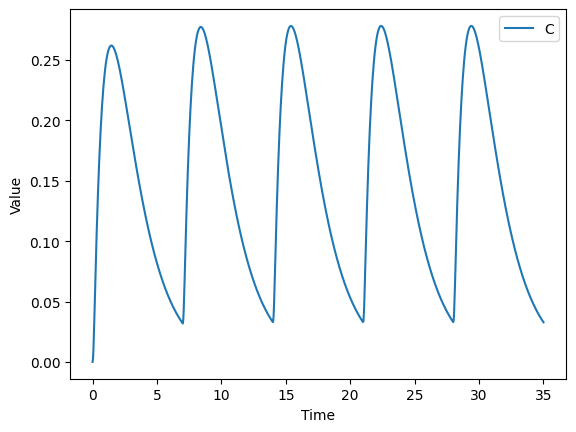

In [10]:
scipy_model = ScipyModel(model=filename)
scipy_model.update_constants(OralDose=50)
scipy_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=scipy_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)
solution.plot_results(variables='C')

# Jax

<Axes: xlabel='Time', ylabel='Value'>

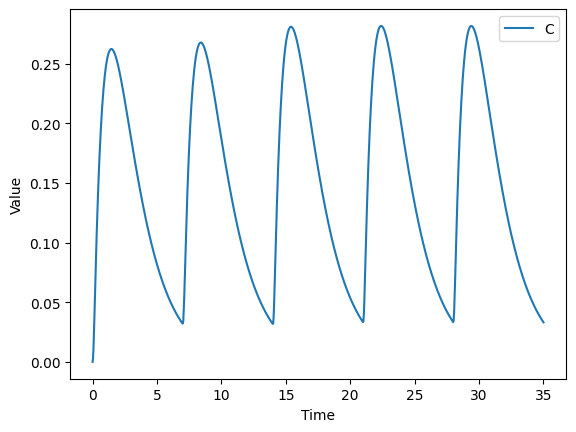

In [9]:
jax_model = JaxModel(model=filename)
jax_model.update_constants(OralDose=50)
jax_model.assign_forcing_function('OralExp', 'PerDose', t0=0, duration=scipy_model.parameters['OralDur'], period=7)
times = np.linspace(0, 35, 1000)
solution = jax_model.run_model(times)
solution.plot_results(variables='C')